# Part 2 - Regularization & Augmentation (IR)

Select a model with modest overfitting from Part 1, then experiment with:
- **2A:** L2 regularization (4 values)
- **2B:** Dropout (4 values)
- **2C:** Data augmentation (4 levels)
- **2D:** Combined (4 options)

Each experiment produces a 4-panel figure.

In [1]:
import torch
from models import build_cnn
from training import get_dataloaders, train_model, get_augmentation
from analysis import plot_4panel, plot_training_curves, print_results_table

MANIFEST = "manifests/ir_manifest.csv"
MODALITY = "IR"
BATCH_SIZE = 256
EPOCHS = 70
LR = 1e-3
MIN_EPOCHS = 50
PATIENCE = 10

# SELECT THE ARCHITECTURE WITH MODEST OVERFITTING FROM PART 1
# Change this based on your Part 1 results
BASE_ARCH = "D"  # Most likely to overfit

print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"Base architecture: {BASE_ARCH}")

Device: NVIDIA GeForce RTX 5090
Base architecture: D


In [2]:
# Default data loaders (no augmentation)
train_loader, val_loader, train_df, val_df = get_dataloaders(
    MANIFEST, batch_size=BATCH_SIZE, num_workers=4
)
print(f"Train: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}")

Windows detected: forcing num_workers=0 to avoid duplicate worker launches.
Train: 41,801 | Val: 11,129


## 2A: L2 Regularization (Weight Decay)

In [3]:
l2_values = [1e-5, 1e-4, 1e-3, 1e-2]
l2_results = []

for wd in l2_values:
    print(f"\n{'='*50}")
    print(f"L2 weight_decay = {wd}")
    print(f"{'='*50}")

    model, count = build_cnn(BASE_ARCH)
    history = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, weight_decay=wd,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_ir_l2_{wd}"
    )

    l2_results.append({
        "label": f"L2={wd}",
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(l2_results)


L2 weight_decay = 1e-05
  Epoch   1/70 | Loss: 0.5695/2.8007 | Acc: 0.8285/0.4272 | F1: 0.8012/0.3600 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.1242/0.4367 | Acc: 0.9584/0.8581 | F1: 0.9575/0.8493 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.0457/0.4812 | Acc: 0.9842/0.8910 | F1: 0.9842/0.8798 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.0390/0.9195 | Acc: 0.9862/0.8669 | F1: 0.9862/0.8345 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.0025/0.7069 | Acc: 0.9994/0.8944 | F1: 0.9994/0.8755 | LR: 5.00e-04
  Epoch  25/70 | Loss: 0.0003/0.8135 | Acc: 1.0000/0.8922 | F1: 1.0000/0.8700 | LR: 2.50e-04
  Epoch  30/70 | Loss: 0.0002/0.8528 | Acc: 1.0000/0.8913 | F1: 1.0000/0.8684 | LR: 2.50e-04
  Epoch  35/70 | Loss: 0.0001/0.8268 | Acc: 1.0000/0.8919 | F1: 1.0000/0.8692 | LR: 1.25e-04
  Epoch  40/70 | Loss: 0.0001/0.8411 | Acc: 1.0000/0.8914 | F1: 1.0000/0.8678 | LR: 6.25e-05
  Epoch  45/70 | Loss: 0.0001/0.7802 | Acc: 1.0000/0.8933 | F1: 1.0000/0.8719 | LR: 3.13e-05
  Epoch  50/70 | Loss: 0.0001/0.7876 | Acc: 1

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part2a_ir_l2.png


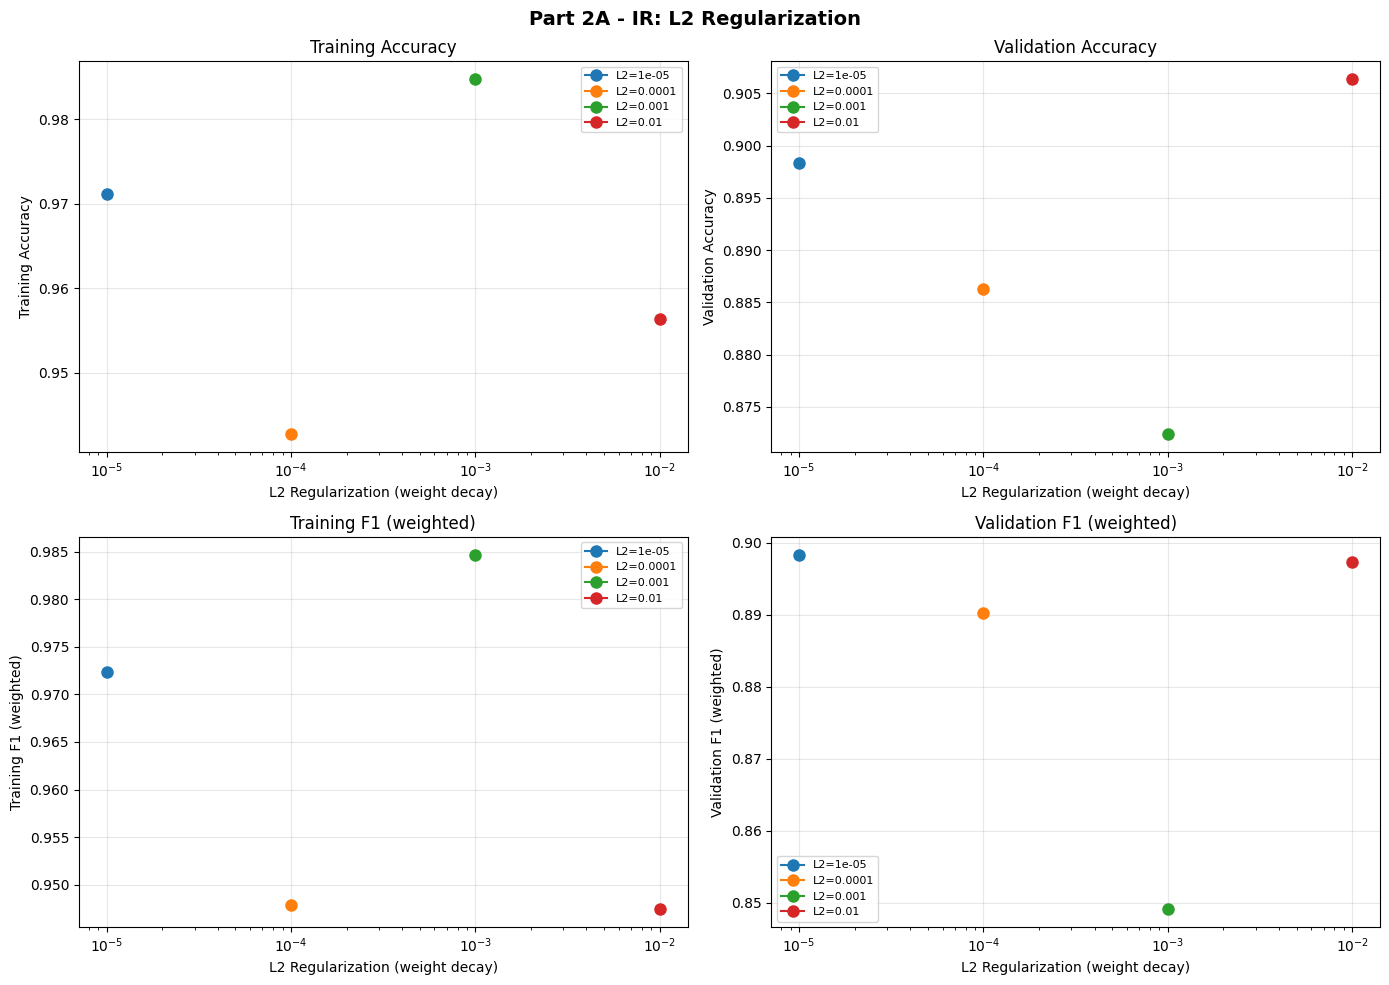

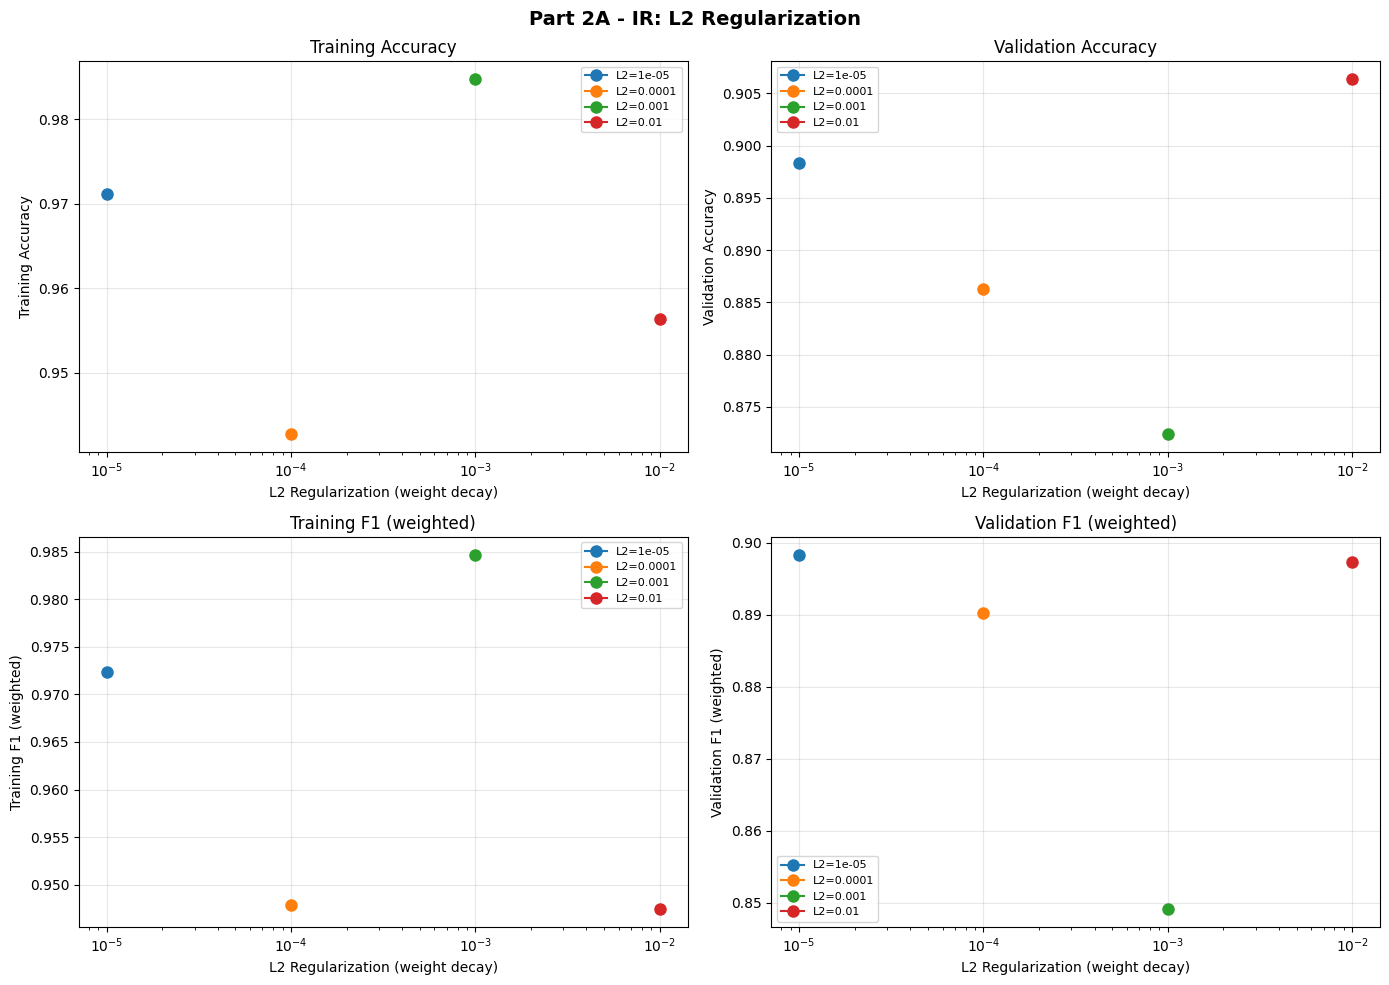

In [4]:
plot_4panel(
    l2_results, l2_values,
    x_label="L2 Regularization (weight decay)",
    title=f"Part 2A - {MODALITY}: L2 Regularization",
    x_log=True,
    save_name=f"part2a_{MODALITY.lower()}_l2.png"
)

## 2B: Dropout

In [5]:
dropout_values = [0.1, 0.25, 0.4, 0.6]
dropout_results = []

for dp in dropout_values:
    print(f"\n{'='*50}")
    print(f"Dropout = {dp}")
    print(f"{'='*50}")

    model, count = build_cnn(BASE_ARCH, dropout=dp)
    history = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_ir_drop_{dp}"
    )

    dropout_results.append({
        "label": f"Drop={dp}",
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(dropout_results)


Dropout = 0.1
  Epoch   1/70 | Loss: 0.7203/0.7620 | Acc: 0.7615/0.7910 | F1: 0.7306/0.7344 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.1824/0.3104 | Acc: 0.9400/0.8778 | F1: 0.9374/0.8614 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.0964/0.5000 | Acc: 0.9674/0.8748 | F1: 0.9669/0.8424 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.0288/0.5815 | Acc: 0.9899/0.8853 | F1: 0.9899/0.8631 | LR: 5.00e-04
  Epoch  20/70 | Loss: 0.0209/0.7856 | Acc: 0.9928/0.8904 | F1: 0.9928/0.8729 | LR: 5.00e-04
  Epoch  25/70 | Loss: 0.0074/0.9142 | Acc: 0.9977/0.8827 | F1: 0.9977/0.8537 | LR: 2.50e-04
  Epoch  30/70 | Loss: 0.0036/0.7984 | Acc: 0.9988/0.8924 | F1: 0.9988/0.8705 | LR: 1.25e-04
  Epoch  35/70 | Loss: 0.0024/0.8999 | Acc: 0.9994/0.8875 | F1: 0.9994/0.8614 | LR: 6.25e-05
  Epoch  40/70 | Loss: 0.0021/0.8680 | Acc: 0.9995/0.8904 | F1: 0.9995/0.8675 | LR: 3.13e-05
  Epoch  45/70 | Loss: 0.0020/0.8554 | Acc: 0.9995/0.8892 | F1: 0.9995/0.8647 | LR: 1.56e-05
  Epoch  50/70 | Loss: 0.0017/0.8767 | Acc: 0.9995/0.88

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part2b_ir_dropout.png


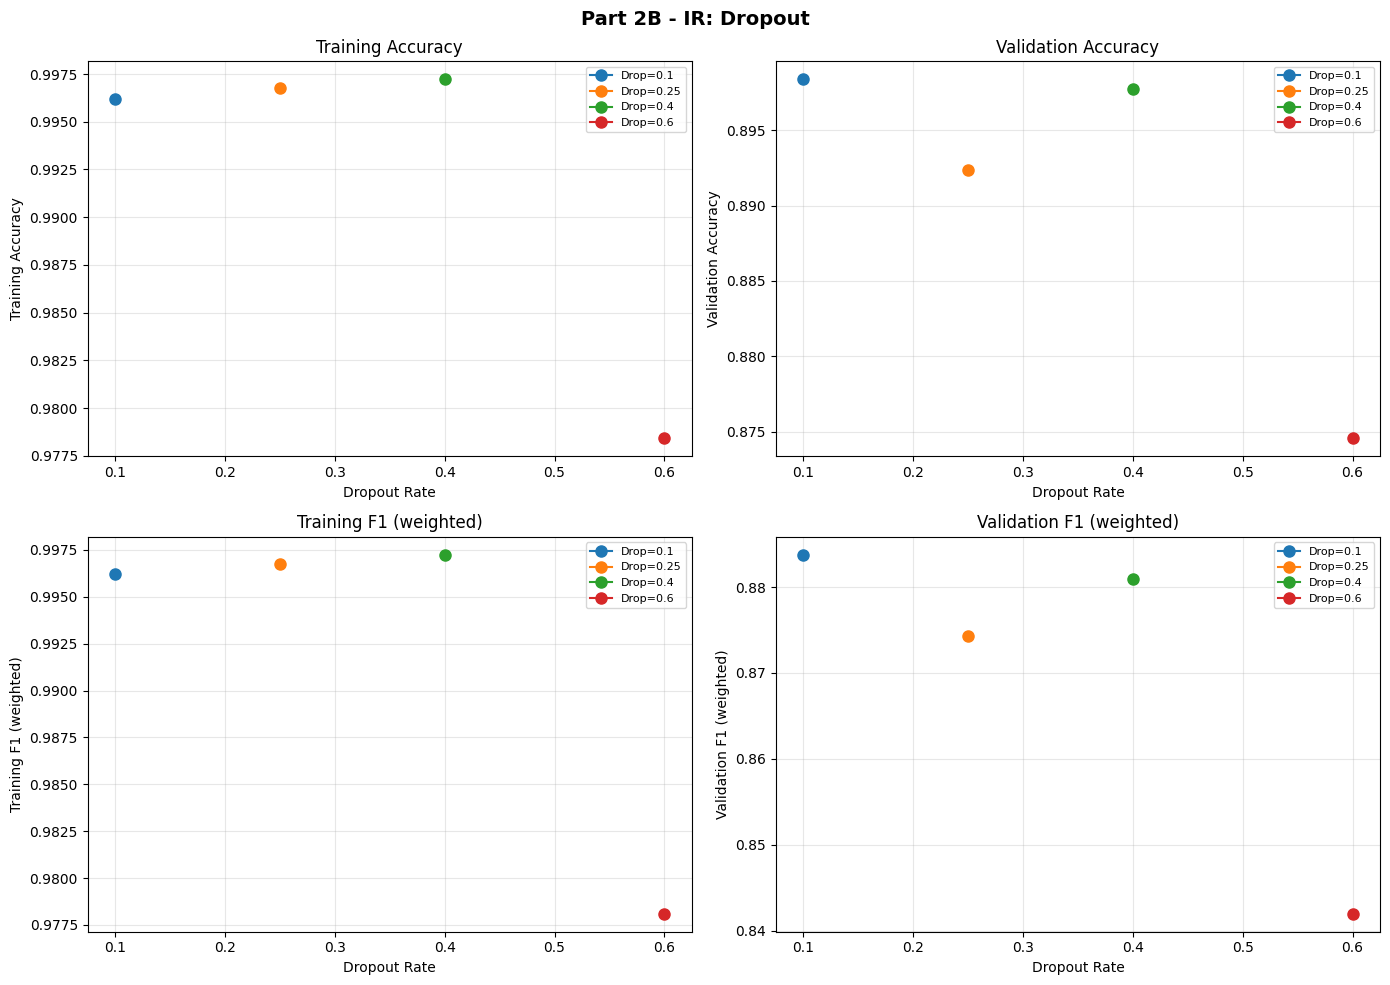

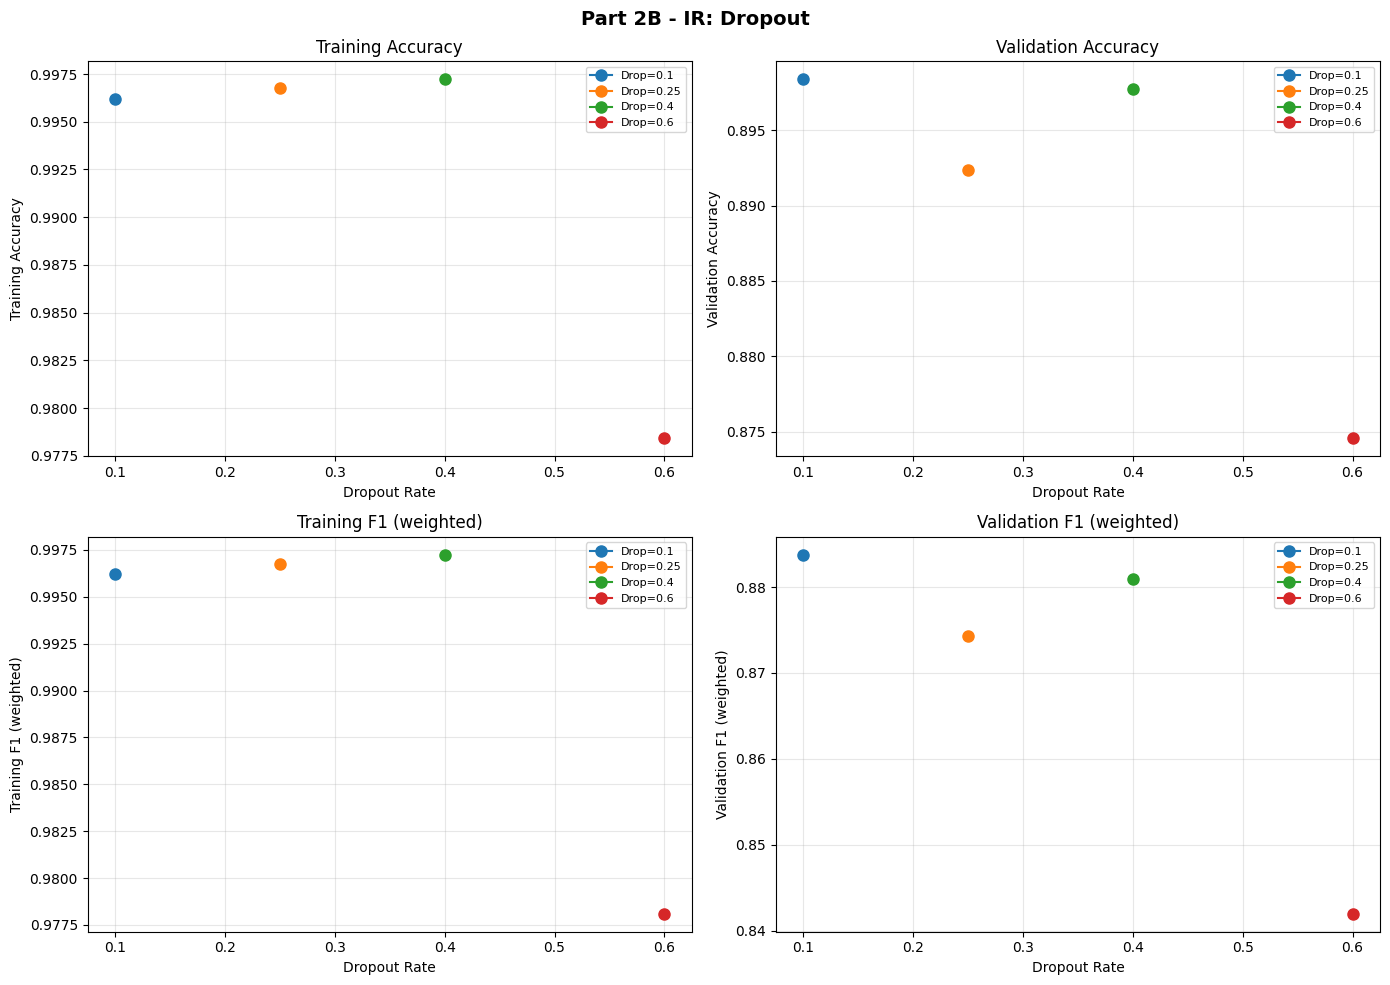

In [6]:
plot_4panel(
    dropout_results, dropout_values,
    x_label="Dropout Rate",
    title=f"Part 2B - {MODALITY}: Dropout",
    save_name=f"part2b_{MODALITY.lower()}_dropout.png"
)

## 2C: Data Augmentation

In [7]:
from torchvision import transforms

aug_levels = [1, 2, 3, 4]
aug_labels = ["Flip only", "Flip+Rot10+Affine", "Flip+Rot20+Affine+Color", "Flip+Rot30+Affine+StrongColor"]
aug_results = []

val_transform = get_augmentation(0)  # No augmentation for validation

for level, label in zip(aug_levels, aug_labels):
    print(f"\n{'='*50}")
    print(f"Augmentation Level {level}: {label}")
    print(f"{'='*50}")

    train_transform = get_augmentation(level)
    aug_train_loader, aug_val_loader, _, _ = get_dataloaders(
        MANIFEST, batch_size=BATCH_SIZE, num_workers=4,
        train_transform=train_transform, val_transform=val_transform
    )

    model, count = build_cnn(BASE_ARCH)
    history = train_model(
        model, aug_train_loader, aug_val_loader,
        epochs=EPOCHS, lr=LR,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_ir_aug_{level}"
    )

    aug_results.append({
        "label": f"Aug L{level}",
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(aug_results)


Augmentation Level 1: Flip only
Windows detected: forcing num_workers=0 to avoid duplicate worker launches.
  Epoch   1/70 | Loss: 0.5314/1.1589 | Acc: 0.8300/0.6594 | F1: 0.8074/0.6139 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.1382/0.6739 | Acc: 0.9540/0.8164 | F1: 0.9525/0.7849 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.0685/0.7127 | Acc: 0.9762/0.8437 | F1: 0.9759/0.8119 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.0359/1.3252 | Acc: 0.9882/0.8119 | F1: 0.9881/0.7808 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.0063/0.5204 | Acc: 0.9983/0.9085 | F1: 0.9983/0.8967 | LR: 5.00e-04
  Epoch  25/70 | Loss: 0.0018/0.7904 | Acc: 0.9995/0.8896 | F1: 0.9995/0.8692 | LR: 5.00e-04
  Epoch  30/70 | Loss: 0.0013/0.9962 | Acc: 0.9996/0.8909 | F1: 0.9996/0.8681 | LR: 2.50e-04
  Epoch  35/70 | Loss: 0.0003/0.9488 | Acc: 0.9999/0.8953 | F1: 0.9999/0.8747 | LR: 1.25e-04
  Epoch  40/70 | Loss: 0.0001/0.9522 | Acc: 1.0000/0.8967 | F1: 1.0000/0.8764 | LR: 6.25e-05
  Epoch  45/70 | Loss: 0.0001/0.9878 | Acc: 0.9999/0.8

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part2c_ir_augmentation.png


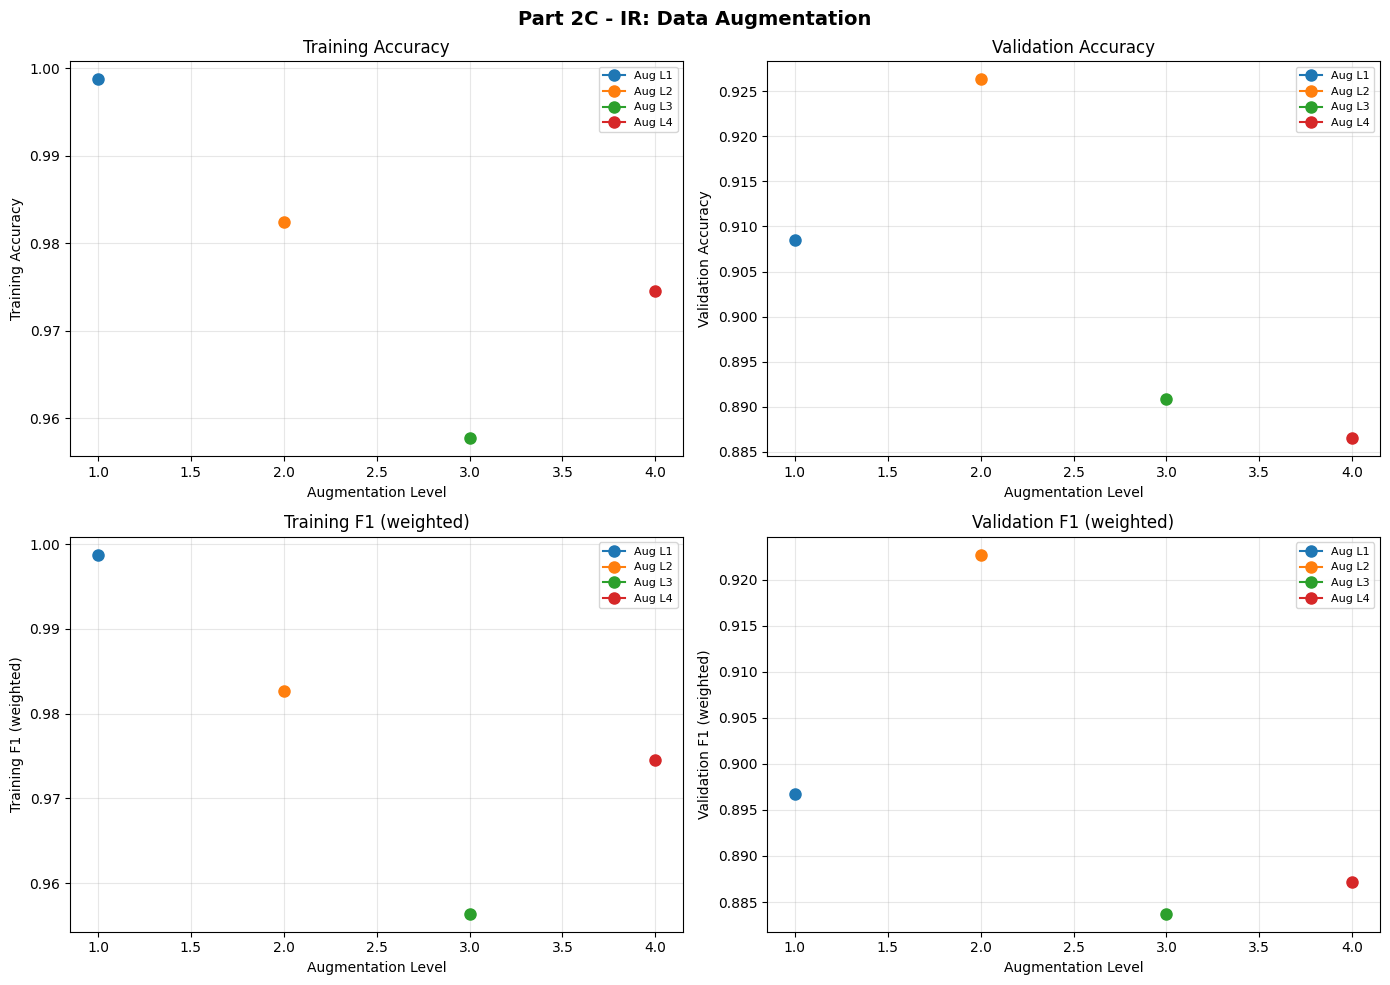

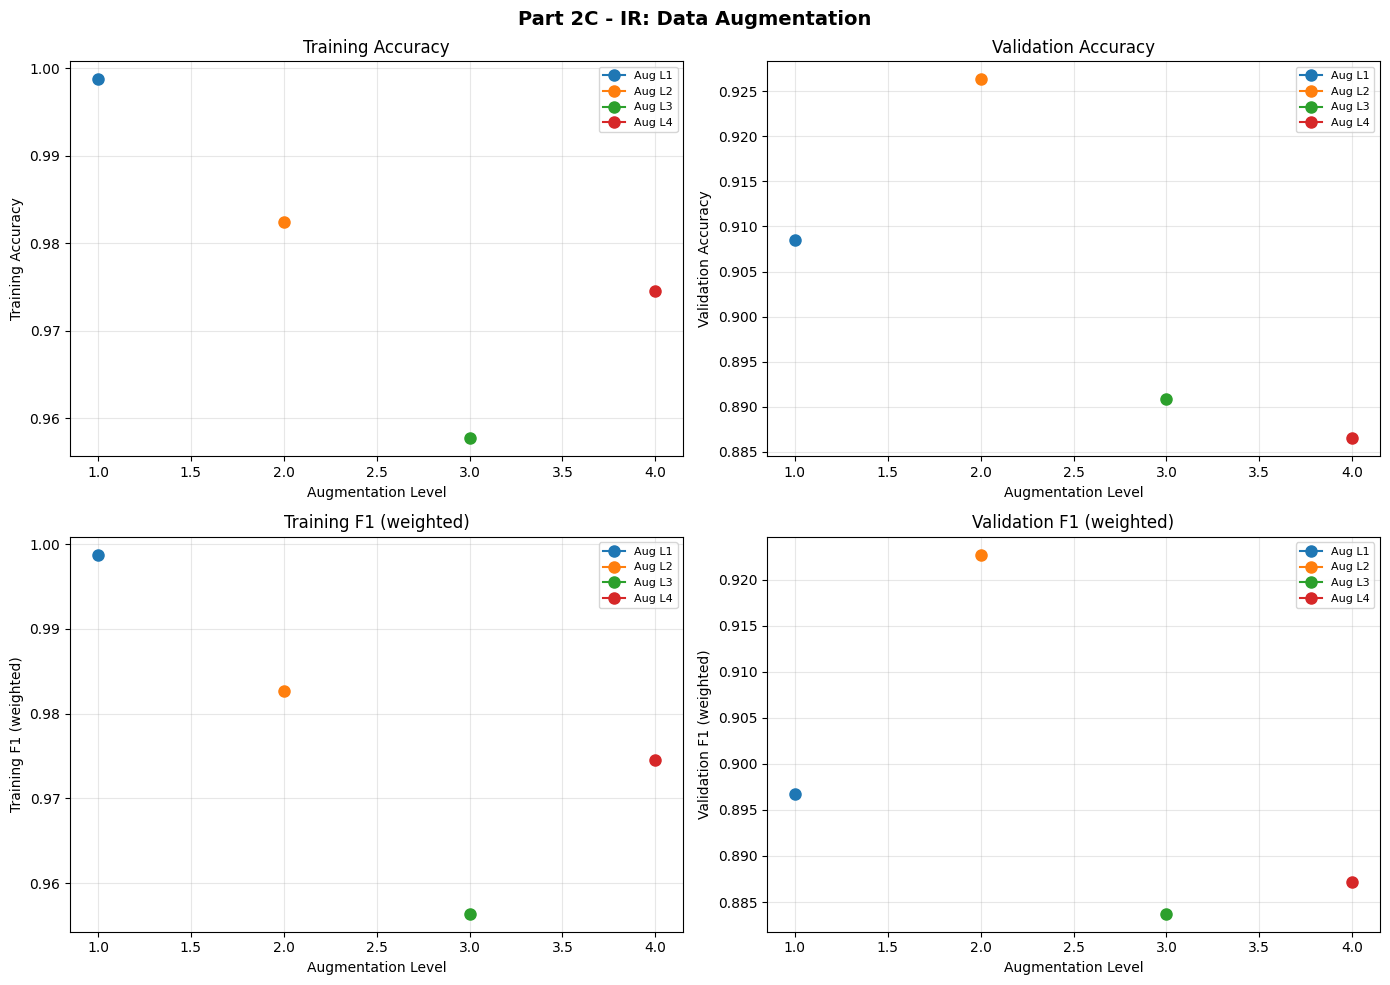

In [8]:
plot_4panel(
    aug_results, aug_levels,
    x_label="Augmentation Level",
    title=f"Part 2C - {MODALITY}: Data Augmentation",
    save_name=f"part2c_{MODALITY.lower()}_augmentation.png"
)

## 2D: Combined (Best L2 + Dropout + Augmentation)

In [9]:
# Identify best from each experiment above
best_l2 = l2_values[max(range(len(l2_results)), key=lambda i: l2_results[i]["best_val_f1"])]
best_dp = dropout_values[max(range(len(dropout_results)), key=lambda i: dropout_results[i]["best_val_f1"])]
best_aug = aug_levels[max(range(len(aug_results)), key=lambda i: aug_results[i]["best_val_f1"])]

print(f"Best L2: {best_l2}")
print(f"Best Dropout: {best_dp}")
print(f"Best Augmentation Level: {best_aug}")

# 4 combined configurations
combined_configs = [
    {"label": f"L2={best_l2}+Drop={best_dp}",
     "wd": best_l2, "dp": best_dp, "aug": 0},
    {"label": f"L2={best_l2}+Aug={best_aug}",
     "wd": best_l2, "dp": 0.0, "aug": best_aug},
    {"label": f"Drop={best_dp}+Aug={best_aug}",
     "wd": 0.0, "dp": best_dp, "aug": best_aug},
    {"label": f"L2+Drop+Aug (all best)",
     "wd": best_l2, "dp": best_dp, "aug": best_aug},
]

Best L2: 1e-05
Best Dropout: 0.1
Best Augmentation Level: 2


In [10]:
combined_results = []
val_transform = get_augmentation(0)

for i, cfg in enumerate(combined_configs):
    print(f"\n{'='*50}")
    print(f"Combined {i+1}: {cfg['label']}")
    print(f"{'='*50}")

    train_transform = get_augmentation(cfg["aug"])
    c_train_loader, c_val_loader, _, _ = get_dataloaders(
        MANIFEST, batch_size=BATCH_SIZE, num_workers=4,
        train_transform=train_transform, val_transform=val_transform
    )

    model, count = build_cnn(BASE_ARCH, dropout=cfg["dp"])
    history = train_model(
        model, c_train_loader, c_val_loader,
        epochs=EPOCHS, lr=LR, weight_decay=cfg["wd"],
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_ir_combined_{i}"
    )

    combined_results.append({
        "label": cfg["label"],
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(combined_results)


Combined 1: L2=1e-05+Drop=0.1
Windows detected: forcing num_workers=0 to avoid duplicate worker launches.
  Epoch   1/70 | Loss: 0.7070/0.9444 | Acc: 0.7719/0.7075 | F1: 0.7395/0.6524 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.1830/0.6665 | Acc: 0.9408/0.8437 | F1: 0.9383/0.8097 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.0905/0.6270 | Acc: 0.9694/0.8685 | F1: 0.9689/0.8324 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.0277/0.6613 | Acc: 0.9906/0.8842 | F1: 0.9906/0.8562 | LR: 5.00e-04
  Epoch  20/70 | Loss: 0.0108/0.9127 | Acc: 0.9965/0.8748 | F1: 0.9965/0.8461 | LR: 2.50e-04
  Epoch  25/70 | Loss: 0.0072/1.0000 | Acc: 0.9977/0.8795 | F1: 0.9977/0.8487 | LR: 1.25e-04
  Epoch  30/70 | Loss: 0.0048/1.1343 | Acc: 0.9984/0.8778 | F1: 0.9984/0.8454 | LR: 1.25e-04
  Epoch  35/70 | Loss: 0.0037/1.1132 | Acc: 0.9988/0.8788 | F1: 0.9988/0.8472 | LR: 6.25e-05
  Epoch  40/70 | Loss: 0.0027/1.0662 | Acc: 0.9993/0.8809 | F1: 0.9993/0.8496 | LR: 3.13e-05
  Epoch  45/70 | Loss: 0.0025/1.0601 | Acc: 0.9994/0.881

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part2d_ir_combined.png


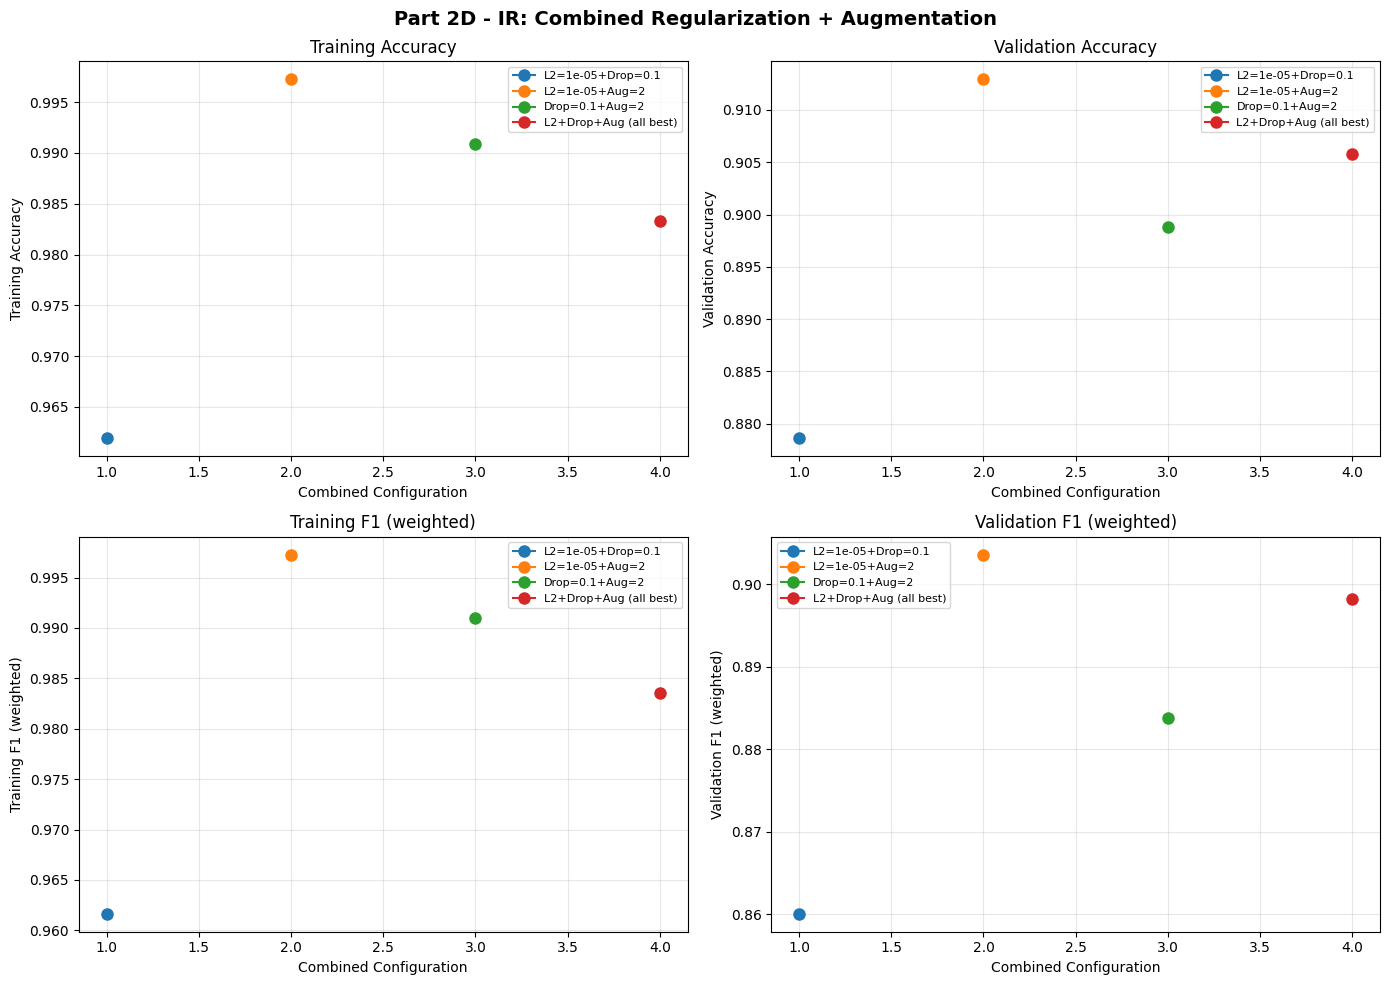

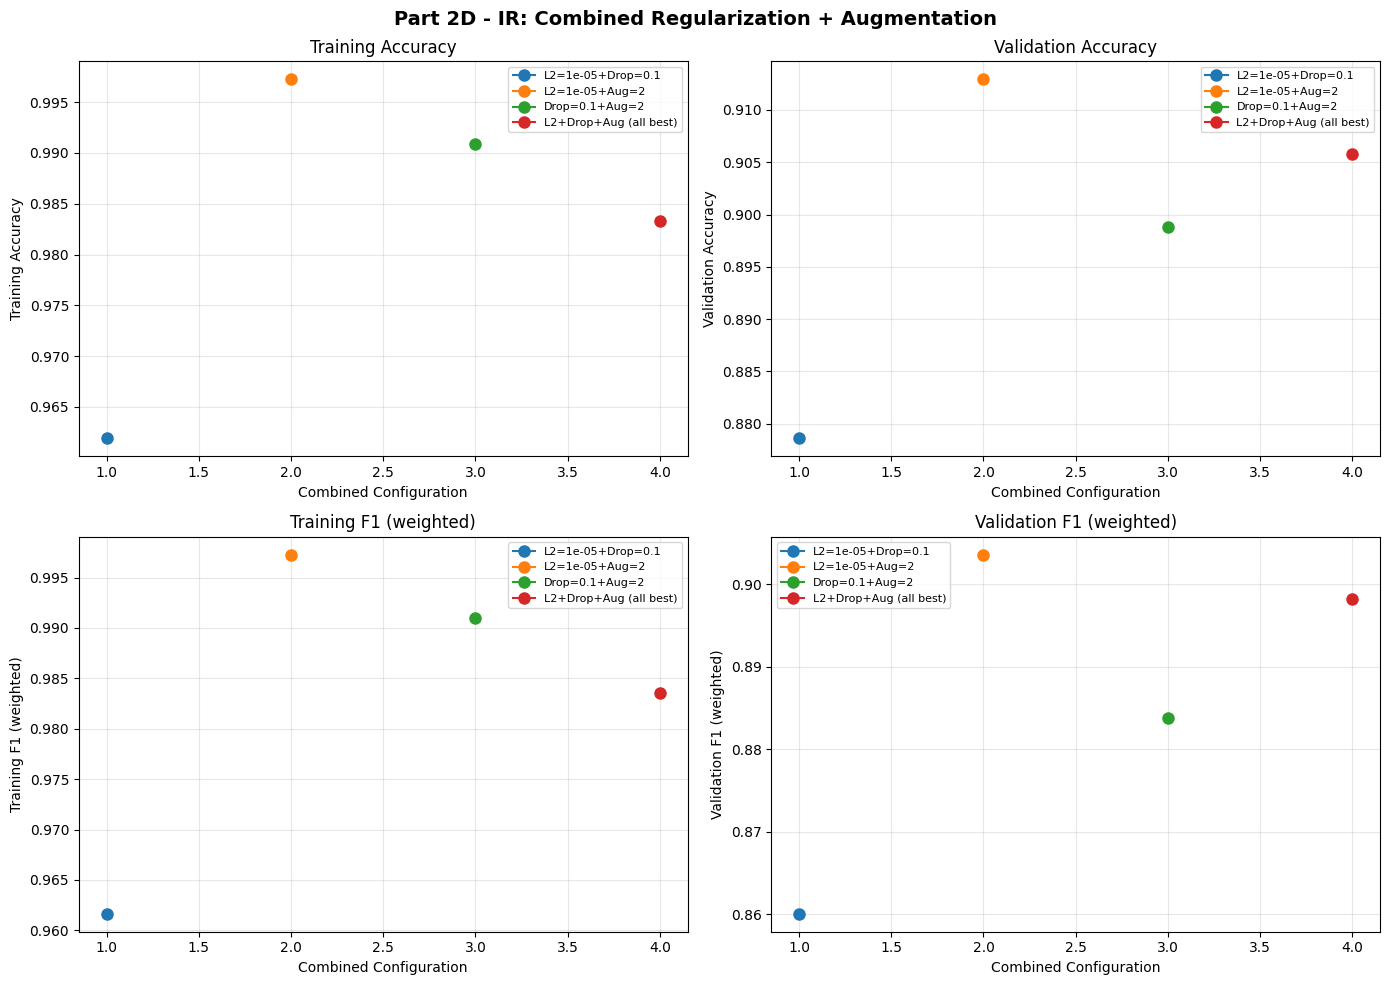

In [11]:
plot_4panel(
    combined_results, list(range(1, 5)),
    x_label="Combined Configuration",
    title=f"Part 2D - {MODALITY}: Combined Regularization + Augmentation",
    save_name=f"part2d_{MODALITY.lower()}_combined.png"
)

## Summary

In [12]:
print(f"\n{'='*60}")
print(f"Part 2 {MODALITY} Summary")
print(f"{'='*60}")
print("\n2A - L2 Regularization:")
print_results_table(l2_results)
print("\n2B - Dropout:")
print_results_table(dropout_results)
print("\n2C - Data Augmentation:")
print_results_table(aug_results)
print("\n2D - Combined:")
print_results_table(combined_results)


Part 2 IR Summary

2A - L2 Regularization:
Label                    Params  Best Ep  Train Acc    Val Acc   Train F1     Val F1
------------------------------------------------------------------------------------
L2=1e-05              2,459,848       12     0.9712     0.8984     0.9723     0.8984
L2=0.0001             2,459,848       20     0.9428     0.8862     0.9478     0.8903
L2=0.001              2,459,848       14     0.9848     0.8724     0.9847     0.8491
L2=0.01               2,459,848       38     0.9564     0.9064     0.9474     0.8973

2B - Dropout:
Label                    Params  Best Ep  Train Acc    Val Acc   Train F1     Val F1
------------------------------------------------------------------------------------
Drop=0.1              2,459,848       14     0.9962     0.8984     0.9962     0.8838
Drop=0.25             2,459,848       31     0.9968     0.8924     0.9968     0.8743
Drop=0.4              2,459,848       42     0.9972     0.8977     0.9972     0.8809
Drop=0